In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [9]:
df = pd.read_csv("./data/processed/hotel_bookings_processed.csv")

In [ ]:
# 1. Definir o alvo
y = df['faixa_preco']

# 2. Remover colunas proibidas (Leakage) ou inúteis
colunas_para_remover = [
    'faixa_preco',              # É o alvo
    'adr',                      # LEAKAGE GRAVE (é a resposta)
    'reservation_status',       # Dado do futuro
    'arrival_date_year',        # Viés temporal
    'arrival_date_day_of_month' # Ruído
]

X = df.drop(columns=colunas_para_remover)

# 3. Transformar variáveis categóricas em números (One-Hot Encoding)
# O pandas detecta automaticamente as colunas de texto e cria as dummies
X = pd.get_dummies(X, columns=[
    'meal', 
    'market_segment', 
    'reserved_room_type', 
    'arrival_date_month'
], drop_first=True)

# 4. Verificar o resultado final
print(f"Colunas finais para treino: {X.shape[1]}")
print(X.head())

In [25]:
# 1. Divisão de Treino e Teste
# Separamos 80% dos dados para o modelo estudar e 20% para uma "prova final"
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Árvore de Decisão

In [26]:
# 2. Criação do Modelo
# max_depth=5 limita a profundidade para a árvore não decorar os dados (Overfitting)
modelo = DecisionTreeClassifier(max_depth=12, random_state=42)

In [28]:
# 4. Previsão
y_pred = modelo.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

   Econômica       0.61      0.68      0.64      3969
        Luxo       0.64      0.70      0.67      3633
      Padrão       0.52      0.33      0.40      3884
     Premium       0.48      0.55      0.52      4132

    accuracy                           0.57     15618
   macro avg       0.56      0.57      0.56     15618
weighted avg       0.56      0.57      0.56     15618



In [20]:
# 5. Avaliação
print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred))

Relatório de Classificação:

              precision    recall  f1-score   support

   Econômica       0.61      0.68      0.64      3969
        Luxo       0.64      0.70      0.67      3633
      Padrão       0.52      0.33      0.40      3884
     Premium       0.48      0.55      0.52      4132

    accuracy                           0.57     15618
   macro avg       0.56      0.57      0.56     15618
weighted avg       0.56      0.57      0.56     15618



### Random Forest

In [29]:
# 1. Divisão de Treino e Teste
# Separamos 80% dos dados para o modelo estudar e 20% para uma "prova final"
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:

from sklearn.ensemble import RandomForestClassifier 
# Substitua o DecisionTree por este:
modelo = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

In [31]:
# 3. Treinamento (O momento em que o modelo aprende)
modelo.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [ ]:
# 4. Previsão
y_pred = modelo.predict(X_test)

In [33]:
# 5. Avaliação
print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred))

Relatório de Classificação:

              precision    recall  f1-score   support

   Econômica       0.65      0.73      0.69      3969
        Luxo       0.73      0.71      0.72      3633
      Padrão       0.61      0.40      0.48      3884
     Premium       0.52      0.64      0.57      4132

    accuracy                           0.62     15618
   macro avg       0.63      0.62      0.61     15618
weighted avg       0.62      0.62      0.61     15618



##### Melhorando a Acurácia

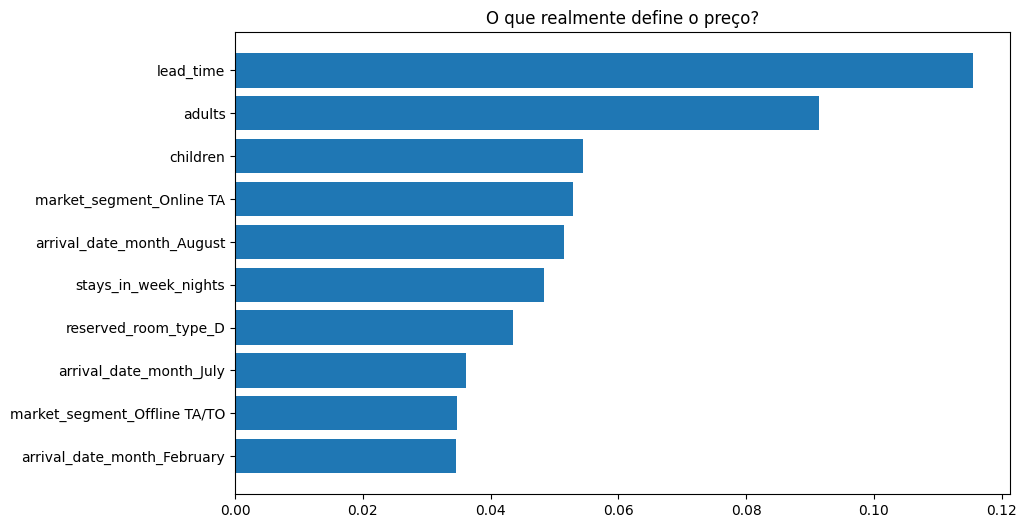

In [ ]:
### Colunas que mais influenciam nas decisões


import matplotlib.pyplot as plt

# Pegando a importância
importancias = modelo.feature_importances_
nomes_colunas = X_train.columns

# Criando um DataFrame para visualizar
df_importancia = pd.DataFrame({'Feature': nomes_colunas, 'Importance': importancias})
df_importancia = df_importancia.sort_values(by='Importance', ascending=False)

# Plotando
plt.figure(figsize=(10, 6))
plt.barh(df_importancia['Feature'][:10], df_importancia['Importance'][:10])
plt.gca().invert_yaxis()
plt.title('O que realmente define o preço?')
plt.show()

In [35]:
### Teste de combinações

from sklearn.model_selection import GridSearchCV

# Definir as combinações que queremos testar
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=modelo, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print(f"Melhores parâmetros: {grid_search.best_params_}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   2.8s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   2.9s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   2.6s
[CV] END max_depth=10, min_samples_split=2, n_estimators=200; total time=   5.5s
[CV] END max_depth=10, min_samples_split=2, n_estimators=200; total time=   6.0s
[CV] END max_depth=10, min_samples_split=2, n_estimators=200; total time=   5.9s
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   2.8s


/usr/local/python/3.12.1/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   2.8s
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   2.9s
[CV] END max_depth=10, min_samples_split=5, n_estimators=200; total time=   5.3s
[CV] END max_depth=10, min_samples_split=5, n_estimators=200; total time=   5.5s
[CV] END max_depth=15, min_samples_split=2, n_estimators=100; total time=   4.5s
[CV] END max_depth=10, min_samples_split=5, n_estimators=200; total time=   5.9s
[CV] END max_depth=15, min_samples_split=2, n_estimators=100; total time=   4.0s
[CV] END max_depth=15, min_samples_split=2, n_estimators=100; total time=   4.1s
[CV] END max_depth=15, min_samples_split=2, n_estimators=200; total time=   7.7s
[CV] END max_depth=15, min_samples_split=2, n_estimators=200; total time=   7.6s
[CV] END max_depth=15, min_samples_split=5, n_estimators=100; total time=   4.4s
[CV] END max_depth=15, min_samples_split=2, n_estimators=200; total time=   7.6s
[CV] END max_depth=15, min_s

##### Aplicando melhorias

In [37]:
# 1. Pequena Engenharia de Features (Baseada no seu gráfico)
# Vamos ajudar o modelo somando as pessoas, já que ambas as colunas são importantes
X_train['total_pessoas'] = X_train['adults'] + X_train['children']
X_test['total_pessoas'] = X_test['adults'] + X_test['children']

# (Opcional) Podemos remover as originais para evitar redundância, ou mantê-las.
# Por enquanto, vamos mantê-las.

# 2. Configurando o Modelo com os "Melhores Parâmetros" do seu GridSearch
modelo_final = RandomForestClassifier(
    n_estimators=200,       # Aumentamos o número de árvores
    max_depth=20,           # Demos mais profundidade
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

# 3. Treinar
modelo_final.fit(X_train, y_train)

# 4. A Hora da Verdade
y_pred_final = modelo_final.predict(X_test)

print("=== Relatório do Modelo Final ===")
print(classification_report(y_test, y_pred_final))

=== Relatório do Modelo Final ===
              precision    recall  f1-score   support

   Econômica       0.69      0.73      0.71      3969
        Luxo       0.73      0.72      0.73      3633
      Padrão       0.62      0.48      0.54      3884
     Premium       0.55      0.65      0.60      4132

    accuracy                           0.65     15618
   macro avg       0.65      0.65      0.65     15618
weighted avg       0.65      0.65      0.64     15618



### Matriz de Confusão

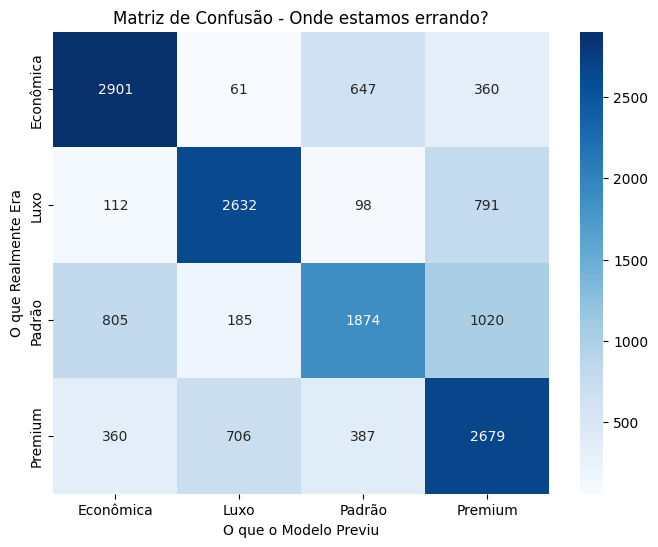

In [39]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Gerar a matriz
cm = confusion_matrix(y_test, y_pred_final)

# Plotar
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=modelo_final.classes_, 
            yticklabels=modelo_final.classes_)
plt.xlabel('O que o Modelo Previu')
plt.ylabel('O que Realmente Era')
plt.title('Matriz de Confusão - Onde estamos errando?')
plt.show()

##### Alternativas para melhoria de Acurácia

In [41]:
###Teste com XBoosting

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# O XGBoost exige que as classes sejam números de 0 a 3 (não strings)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Configuração poderosa
modelo_xgb = XGBClassifier(
    n_estimators=500,       # Mais árvores, pois elas são pequenas
    learning_rate=0.05,     # Aprende devagar para não decorar (Overfitting)
    max_depth=6,            # Profundidade média
    subsample=0.8,          # Usa 80% dos dados por árvore para variar
    colsample_bytree=0.8,   # Usa 80% das colunas por árvore
    random_state=42,
    n_jobs=-1
)

modelo_xgb.fit(X_train, y_train_encoded)

# Previsão
y_pred_xgb = modelo_xgb.predict(X_test)
# Converter de volta para nomes (0 -> Econômica) para o relatório
y_pred_decodificado = le.inverse_transform(y_pred_xgb)

print(classification_report(y_test, y_pred_decodificado))

              precision    recall  f1-score   support

   Econômica       0.67      0.72      0.70      3969
        Luxo       0.72      0.73      0.72      3633
      Padrão       0.59      0.44      0.51      3884
     Premium       0.54      0.62      0.57      4132

    accuracy                           0.63     15618
   macro avg       0.63      0.63      0.63     15618
weighted avg       0.63      0.63      0.62     15618



In [44]:
### Unindo os dois modelos


from sklearn.ensemble import VotingClassifier

# 1. Recriar os modelos com as melhores configurações que achamos até agora
rf_best = RandomForestClassifier(
    n_estimators=200, 
    max_depth=20, 
    min_samples_split=2, 
    random_state=42, 
    n_jobs=-1
)

xgb_best = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,           # AUMENTEI um pouco a profundidade para ajudar
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# 2. Criar o "Super Modelo" de Votação
# voting='soft' usa as probabilidades. voting='hard' usa apenas o voto final (vence a maioria).
# Soft geralmente funciona melhor.
modelo_voto = VotingClassifier(
    estimators=[('rf', rf_best), ('xgb', xgb_best)],
    voting='soft'
)

# 3. Treinar o conjunto
# Nota: Precisamos usar o y_train_encoded (numérico) por causa do XGBoost
modelo_voto.fit(X_train, y_train_encoded)

# 4. Avaliar
y_pred_voto = modelo_voto.predict(X_test)
y_pred_decodificado = le.inverse_transform(y_pred_voto)

print("=== Relatório do Voting Classifier ===")
print(classification_report(y_test, y_pred_decodificado))

=== Relatório do Voting Classifier ===
              precision    recall  f1-score   support

   Econômica       0.71      0.73      0.72      3969
        Luxo       0.74      0.74      0.74      3633
      Padrão       0.63      0.52      0.57      3884
     Premium       0.57      0.65      0.61      4132

    accuracy                           0.66     15618
   macro avg       0.66      0.66      0.66     15618
weighted avg       0.66      0.66      0.66     15618



In [46]:
### Reduzindo o número de classes alvo

# 1. Criar uma cópia da sua coluna alvo original para não perder os dados
y_tres_classes = y.copy()

# 2. Substituir os valores (Fundindo Padrão e Premium)
mapa_fusao = {
    'Econômica': 'Econômica',
    'Padrão': 'Standard',
    'Premium': 'Standard',
    'Luxo': 'Luxo'
}

y_tres_classes = y_tres_classes.map(mapa_fusao)

# 3. Verificar se funcionou (deve ter apenas 3 barras agora)
print(y_tres_classes.value_counts())

faixa_preco
Standard     40254
Econômica    19640
Luxo         18194
Name: count, dtype: int64


In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Nova divisão (usando o y_tres_classes)
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X, y_tres_classes, test_size=0.2, random_state=42
)

# 2. Configurar o modelo (usando os hiperparâmetros que já sabemos que são bons)
modelo_final_3c = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

# 3. Treinar
modelo_final_3c.fit(X_train_3, y_train_3)

# 4. Prever
y_pred_3 = modelo_final_3c.predict(X_test_3)

# 5. Resultado
print("=== Relatório com 3 Classes ===")
print(classification_report(y_test_3, y_pred_3))

=== Relatório com 3 Classes ===
              precision    recall  f1-score   support

   Econômica       0.77      0.61      0.68      3969
        Luxo       0.81      0.65      0.72      3633
    Standard       0.71      0.85      0.78      8016

    accuracy                           0.74     15618
   macro avg       0.76      0.70      0.73     15618
weighted avg       0.75      0.74      0.74     15618



In [49]:
### Aplicando balanceamento automático

modelo_final_balanceado = RandomForestClassifier(
    n_estimators=300,        # Aumentei um pouco para garantir estabilidade
    max_depth=20,
    min_samples_split=2,
    class_weight='balanced', # <--- A MÁGICA ESTÁ AQUI
    random_state=42,
    n_jobs=-1
)

modelo_final_balanceado.fit(X_train_3, y_train_3)

y_pred_bal = modelo_final_balanceado.predict(X_test_3)

print("=== Tentativa Final: 3 Classes Balanceadas ===")
print(classification_report(y_test_3, y_pred_bal))

=== Tentativa Final: 3 Classes Balanceadas ===
              precision    recall  f1-score   support

   Econômica       0.65      0.78      0.71      3969
        Luxo       0.68      0.78      0.73      3633
    Standard       0.78      0.65      0.71      8016

    accuracy                           0.72     15618
   macro avg       0.70      0.74      0.72     15618
weighted avg       0.72      0.72      0.71     15618

